In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


We want to find the $k$-dependent eigenvalues of matrix (4.12) in the Overleaf. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable (no clustering).
The matrix depends on pairwise interaction potential $W$ (rather its Fourier transform). We consider the Gaussian case.

For the wrapped Gaussian defined on $[-L/2,L/2]$ we have that $$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr$$
$$ =- \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr$$
$$= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr$$
$$= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.$$

Alternative: Try non-wrapped Gaussian:
$$
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right)
$$

In [8]:
#Wrapped Gaussian model
σ = np.sqrt(0.5)  # variance
L = 10 # boxlength

def W_hat(k):
    W_hat_k = -np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) #
    return W_hat_k

# non-wrapped case:
#from scipy.special import erf
#def W_hat(k):
#    W_hat_k = -np.sqrt(2*np.pi)*σ * np.exp(-σ**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) )
#    return W_hat_k

# The matrix A. We restrict it to the first "dim" rows.
def matrix(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat(k)/L 
    return A_k

In [9]:
# For a number of temperatures and friction values, obtain largest eigenvalues.
def function():
    N_β = 300    # Number of temperature points.
    N_γ = 3      # Number of friction points.
    β_list = np.linspace(1,20,N_β)
    #γ_list = np.linspace(0.0,1,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    γ_list = np.linspace(0.01,1,1)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    k_max = 50  # number of wavenumbers to test.
    
    approximation_dimension = 50  # number of matrix rows to consider.
    
    # for all beta and gamma...
    for i in range(len(β_list)):
        print("beta: ", i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            
            maximum = np.max(np.real(np.linalg.eigvals(matrix(0.,β,γ,L,approximation_dimension))))
            
            # find maximum eigenvalue for all wavenumbers
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    
    return β_list,γ_list,spectral_radius


# $(2\pi)^{1/2} * \sigma \frac{1}{L}$ in 1D
# $(2\pi) * \sigma^2 \frac{1}{L^2} $ in 2D

In [5]:
for i in range(30 - 1):
    k=2*np.pi*(i+1)/L
    print(np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) ))

NameError: name 'erf' is not defined

In [10]:
# Print critical beta given by literature.
print('Theoretical critcal beta in 1D  ',L/(σ*np.sqrt(2*np.pi)))
print('Theoretical critcal beta in 2D ',L**2/(σ**2*2*np.pi))    


Theoretical critcal beta in 1D   5.6418958354775635
Theoretical critcal beta in 2D  31.83098861837906


In [11]:
# For all temperatures and frictions, obtain largest eigenvalues.
β_list,γ_list,spectral_radius = function()

beta:  0
beta:  1
beta:  2
beta:  3
beta:  4
beta:  5
beta:  6
beta:  7
beta:  8
beta:  9
beta:  10
beta:  11
beta:  12
beta:  13
beta:  14
beta:  15
beta:  16
beta:  17
beta:  18
beta:  19
beta:  20
beta:  21
beta:  22
beta:  23
beta:  24
beta:  25
beta:  26
beta:  27
beta:  28
beta:  29
beta:  30
beta:  31
beta:  32
beta:  33
beta:  34
beta:  35
beta:  36
beta:  37
beta:  38
beta:  39
beta:  40
beta:  41
beta:  42
beta:  43
beta:  44
beta:  45
beta:  46
beta:  47
beta:  48
beta:  49
beta:  50
beta:  51
beta:  52
beta:  53
beta:  54
beta:  55
beta:  56
beta:  57
beta:  58
beta:  59
beta:  60
beta:  61
beta:  62
beta:  63
beta:  64
beta:  65
beta:  66
beta:  67
beta:  68
beta:  69
beta:  70
beta:  71
beta:  72
beta:  73
beta:  74
beta:  75
beta:  76
beta:  77
beta:  78
beta:  79
beta:  80
beta:  81
beta:  82
beta:  83
beta:  84
beta:  85
beta:  86
beta:  87
beta:  88
beta:  89
beta:  90
beta:  91
beta:  92
beta:  93
beta:  94
beta:  95
beta:  96
beta:  97
beta:  98
beta:  99
beta:  100

In [12]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):

gamma_idx = 0 # which gamma to consider (T_crit should be independent of it anyway)
beta_c = β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ]
print("Crit. Beta: ", beta_c )


Crit. Beta:  6.274247491638796


Text(0, 0.5, 'Frequency of phase transition')

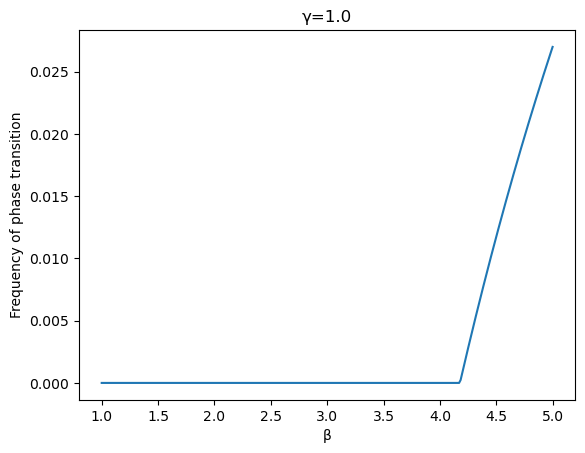

In [115]:
# plot the eigenvalue against beta

plt.plot(β_list,spectral_radius[:,gamma_idx])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')


Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

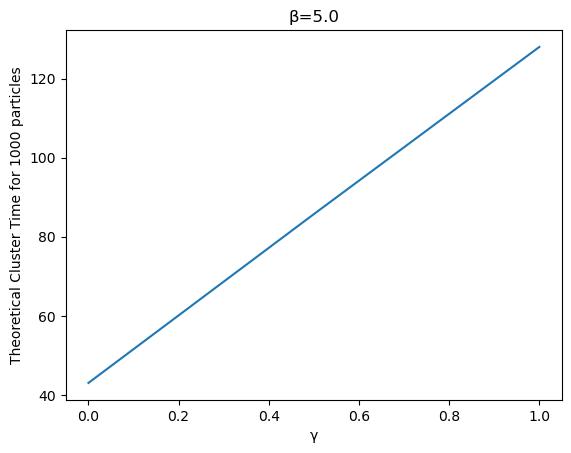

In [114]:
# plot time to onset of clustering (correct formula?)

plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [ ]:
spectral_radius[spectral_radius > 0]

In [ ]:
# create 3D plot of maximum eigenvalue vs. (gamma, beta)

#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Attractive Gaussian Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Von Mises-Fisher

For the Von Mises-Fisher potential defined on $[-L/2,L/2]$ we have that $$W(r) = - I_{0}(\kappa)^{-2}\exp{\left\{\theta\cos(2\pi x/L)\right\}}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)-ikr\right)}dr$$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\cos{(\frac{2\pi z r}{L})}dr. $$

In [ ]:
from scipy.special import jv
from scipy.integrate import quad

θ = 1.
κ = 1

#@numba.jit(nopython=True)
def integrand(r,z):
    #integrate numerically
    des = -np.exp(θ*np.cos(2*np.pi*r/L))*np.cos(z*r)/jv(0, κ)**2
    return des 


def W_hat_VMF(k):
    #integrate numerically
    W_hat_k = quad(integrand,-L/2,L/2,args = (k))
    return W_hat_k[0]


def matrix_VMF(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_VMF(k)/L
    return A_k

In [ ]:
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,1,1.,10,20)))))
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,10,1.,10,20)))))

In [ ]:
def function_VMF():
    N_β = 30
    N_γ = 100
    β_list = np.linspace(0.001,30,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 10
    approximation_dimension = 15
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_VMF(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_VMF(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [ ]:
# β_list,γ_list,spectral_radius = function_VMF()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

In [ ]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [ ]:
plt.plot(β_list,spectral_radius[:,-1])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

In [ ]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Von Mises-Fisher Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Morse potential

For the Morse potential defined on $[-L/2,L/2]$ we have that $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) =  D_e \int^{L/2}_{-L/2} (e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)})\cos{(2\pi zr/L)}dr . $$

In [1]:
from scipy.special import jv
from scipy.integrate import quad

# to do
L  = 10.
De = 1
re = 0
a  = 2

#@numba.jit(nopython=True)
def integrand_MORSE(r,z):
    #integrate numerically
    des = De*(np.exp(-2*a*(np.abs(r)-re))-2*np.exp(-a*(np.abs(r)-re)))*np.cos(z*r)
    return des 


def W_hat_MORSE(k):
    #integrate numerically
    W_hat_k = quad(integrand_MORSE,-L/2,L/2,args = (k,))
    return W_hat_k[0]


def matrix_MORSE(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_MORSE(k)/L
    return A_k



In [14]:
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,1,1.,L,15)))))
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,100,10.,L,15)))))

-0.6026848633007849
0.02261226505106414


In [26]:
def function_MORSE():
    N_β = 300    # Number of temperature points.
    N_γ = 4      # Number of friction points.
    β_list = np.linspace(1,20,N_β)
    γ_list = np.linspace(0.0,1,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    #γ_list = np.linspace(0.01,1,1)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    k_max = 50  # number of wavenumbers to test.
    
    approximation_dimension = 50  # number of matrix rows to consider.
    
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_MORSE(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius



In [27]:
β_list,γ_list,spectral_radius = function_MORSE()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [29]:
# Print the first beta at which eigenvalues become positive (should align with theoretical prediction above):


gamma_idx = 2 # which gamma to consider (T_crit should be independent of it anyway)
beta_c = β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ]
print("Crit. Beta: ", beta_c )




Crit. Beta:  7.545150501672241


In [35]:
print(spectral_radius)


[[ 4.90274488e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 4.97379913e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 5.96855899e-13 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 ...
 [ 1.65096300e-01  1.21392311e-01  8.75166897e-02  6.58714401e-02]
 [ 1.65697745e-01  1.21816677e-01  8.78149142e-02  6.60943488e-02]
 [ 1.66296033e-01  1.22238455e-01  8.81112641e-02  6.63158460e-02]]


Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

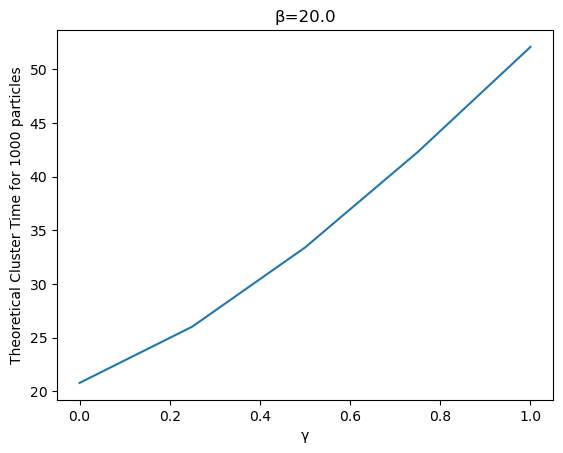

In [19]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

Text(0, 0.5, 'Frequency of phase transition')

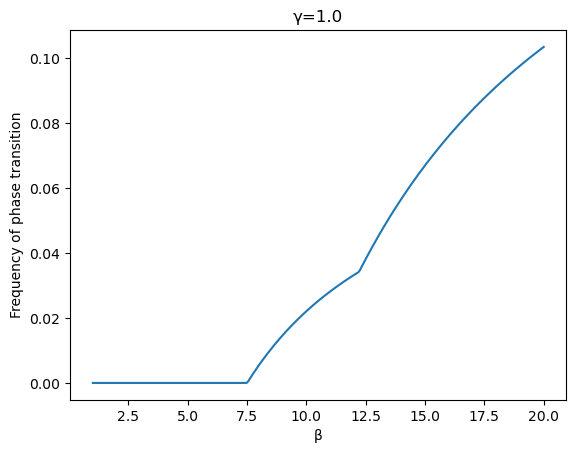

In [20]:
plt.plot(β_list,spectral_radius[:,2])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

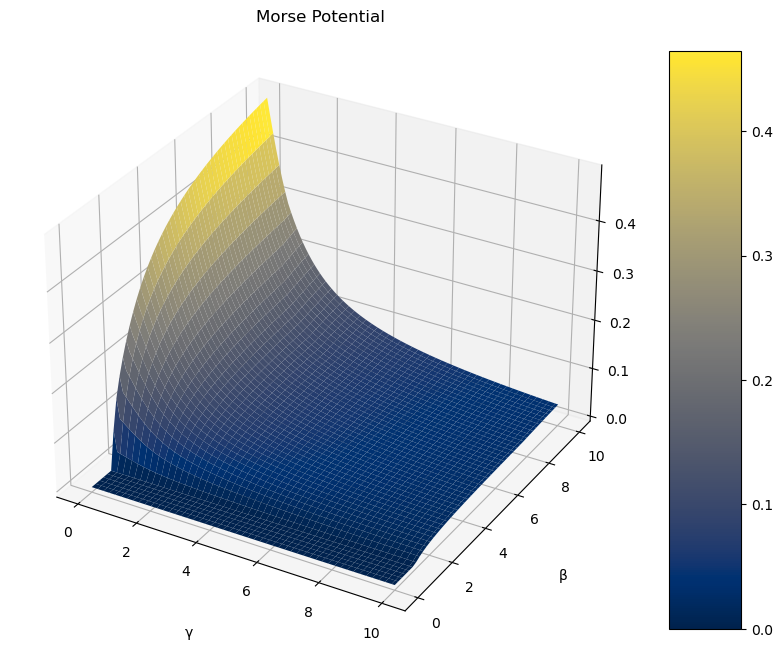

In [50]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Morse Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()